# California Mental Health Services
## Exploratory Data Analysis

**Author:** Kesheka Edupuganti  
**Data Source:** California Health and Human Services Open Data Portal (data.chhs.ca.gov)  
**Dataset:** Behavioral Health Program Performance Data, FY2019-20 to FY2022-23  
**Tools:** Python, Pandas, Seaborn, Matplotlib

**Data note:** All data is sourced directly from the CHHS Open Data Portal using publicly available CSV files. No synthetic data is used in this notebook.

---

## The Question

California spends billions on mental health services every year. But who is actually being served? Are the right people getting access? And which counties are being left behind?

This analysis explores four core questions:
1. How has adult mental health service utilization changed from FY2019-20 to FY2022-23?
2. Which counties have the highest and lowest beneficiary counts?
3. What do the demographics look like across age, sex and race?
4. Where are the trends moving and what do they tell us about access?

## 01  Setup

In [1]:
import sys
!{sys.executable} -m pip install pandas numpy matplotlib seaborn -q

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'figure.facecolor': 'white'
})

GOLD  = '#c8923a'
GREEN = '#1a3a2a'
RED   = '#d4614a'

print('Libraries loaded.')

Libraries loaded.


## 02  Data Loading

Four CSV files downloaded from the CHHS Open Data Portal.

Download from: https://data.chhs.ca.gov/dataset/behavioral-health-program-performance-data

In [6]:
# Load all four CHHS datasets
sex_df  = pd.read_csv('adult_utilization_by_sex.csv')
race_df = pd.read_csv('adult_utilization_by_race.csv')
age_df  = pd.read_csv('adult_utilization_by_age.csv')
demo_df = pd.read_csv('all_demo_data_new_3.csv', encoding='latin-1', engine='python', on_bad_lines='skip')

print(f'Sex data    : {len(sex_df):,} rows')
print(f'Race data   : {len(race_df):,} rows')
print(f'Age data    : {len(age_df):,} rows')
print(f'Demo data   : {len(demo_df):,} rows')
print(f'\nFiscal years: {sorted(sex_df["Fiscal Year"].unique())}')
print(f'Data source : CHHS Open Data Portal (data.chhs.ca.gov)')

Sex data    : 340,839 rows
Race data   : 631,704 rows
Age data    : 544,836 rows
Demo data   : 134,891 rows

Fiscal years: ['2019/20', '2020/21', '2021/22', '2022/23']
Data source : CHHS Open Data Portal (data.chhs.ca.gov)


## 03  Cleaning and Validation

In [7]:
def prepare_utilization(df, demo_group_filter):
    """
    Filter to:
    - Adult population only
    - Beneficiary count (BENE_COUNT) as the measure
    - Specified demographic group
    - Clean county names only (exclude Fee For Service / MCP sub-rows)
    """
    out = df[
        (df['Population Category'] == 'Adult') &
        (df['Units'] == 'BENE_COUNT') &
        (df['Demographic Group'] == demo_group_filter) &
        (~df['Health Care Delivery System'].str.contains(' - ', na=False))
    ].copy()
    out['Amount MH Service Received'] = pd.to_numeric(
        out['Amount MH Service Received'], errors='coerce'
    )
    out = out.rename(columns={
        'Health Care Delivery System': 'county',
        'Fiscal Year': 'fiscal_year',
        'Amount MH Service Received': 'beneficiaries',
        'Medi-Cal Delivery System': 'delivery_system'
    })
    return out[['county','fiscal_year','delivery_system','beneficiaries']]

# All adults (S0 All = total, not broken by sex)
adult_all  = prepare_utilization(sex_df,  'S0 All')
adult_sex  = prepare_utilization(sex_df,  'S1 Female')
adult_male = prepare_utilization(sex_df,  'S2 Male')

print(f'Adult total rows : {len(adult_all):,}')
print(f'Null beneficiaries: {adult_all["beneficiaries"].isnull().sum():,}')
print(f'Counties         : {adult_all["county"].nunique()}')
print(f'Fiscal years     : {sorted(adult_all["fiscal_year"].unique())}')
adult_all.head()

Adult total rows : 40,724
Null beneficiaries: 17,963
Counties         : 224
Fiscal years     : ['2019/20', '2020/21', '2021/22', '2022/23']


,county,fiscal_year,delivery_system,beneficiaries
0,Alameda,2019/20,NSMHS,NaN
4,Alameda,2019/20,NSMHS,NaN
10,Alameda,2019/20,NSMHS,522.0
16,Alameda,2019/20,NSMHS,442.0
22,Alameda,2019/20,NSMHS,NaN


In [8]:
# Aggregate both delivery systems (SMHS + NSMHS) per county per year
county_year = adult_all.groupby(['county','fiscal_year'])['beneficiaries'].sum().reset_index()
county_year = county_year.dropna(subset=['beneficiaries'])

# Statewide totals by year
statewide = county_year.groupby('fiscal_year')['beneficiaries'].sum().reset_index().sort_values('fiscal_year')
statewide['beneficiaries_M'] = (statewide['beneficiaries'] / 1e6).round(3)

print('Statewide adult beneficiaries by year:')
print(statewide[['fiscal_year','beneficiaries_M']].to_string(index=False))

Statewide adult beneficiaries by year:
fiscal_year  beneficiaries_M
    2019/20           13.590
    2020/21           14.020
    2021/22           14.697
    2022/23           16.418


## 04  Statewide Trends

How has total adult mental health service utilization changed across California from FY2019-20 to FY2022-23?

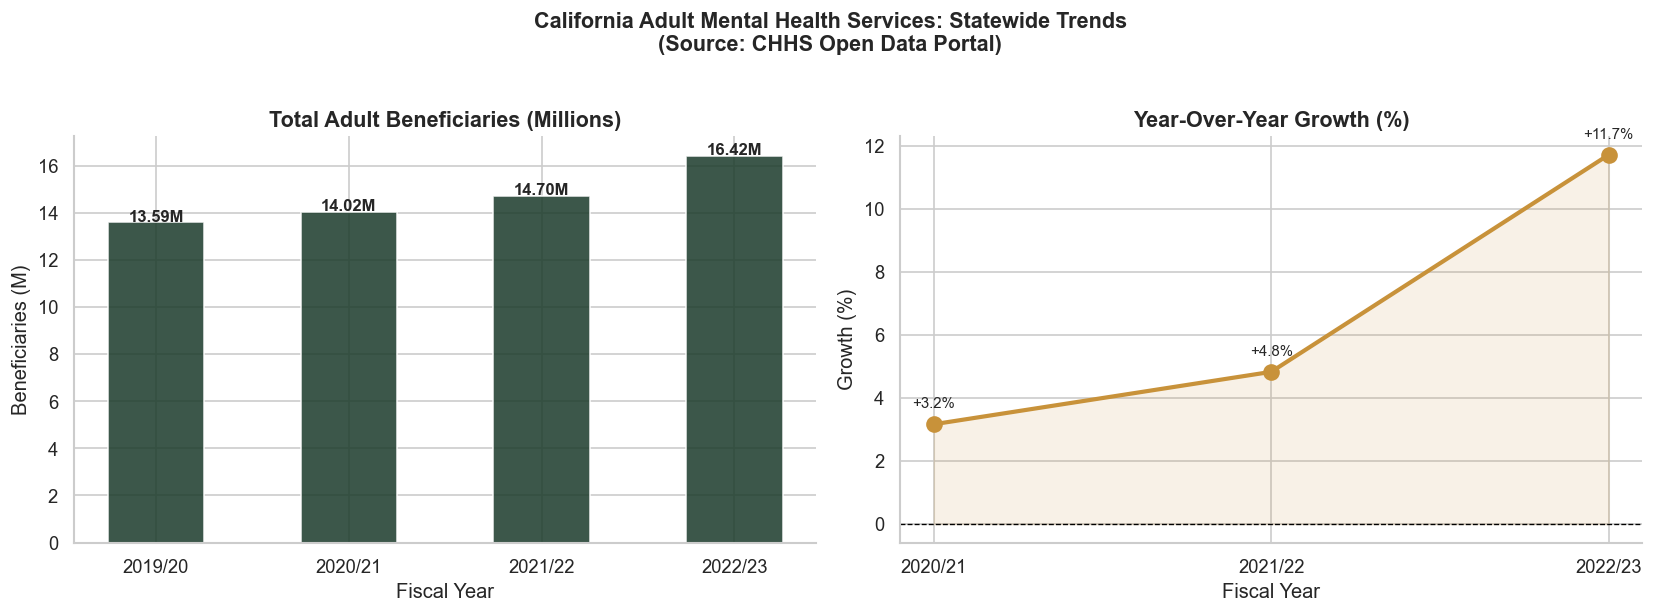

Total growth FY2019-20 to FY2022-23: +20.8%


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('California Adult Mental Health Services: Statewide Trends\n(Source: CHHS Open Data Portal)',
             fontsize=13, fontweight='bold', y=1.02)

# Total beneficiaries bar chart
bars = axes[0].bar(statewide['fiscal_year'], statewide['beneficiaries_M'],
                   color=GREEN, alpha=0.85, width=0.5, edgecolor='white')
axes[0].set_title('Total Adult Beneficiaries (Millions)')
axes[0].set_xlabel('Fiscal Year')
axes[0].set_ylabel('Beneficiaries (M)')
for bar, val in zip(bars, statewide['beneficiaries_M']):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 0.05,
                 f'{val:.2f}M', ha='center', fontsize=10, fontweight='bold')

# Year-over-year growth line
statewide['yoy_growth'] = statewide['beneficiaries'].pct_change() * 100
axes[1].plot(statewide['fiscal_year'], statewide['yoy_growth'],
             marker='o', color=GOLD, linewidth=2.5, markersize=9)
axes[1].fill_between(range(len(statewide)), statewide['yoy_growth'],
                     alpha=0.12, color=GOLD)
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title('Year-Over-Year Growth (%)')
axes[1].set_xlabel('Fiscal Year')
axes[1].set_ylabel('Growth (%)')
for i, (fy, val) in enumerate(zip(statewide['fiscal_year'], statewide['yoy_growth'])):
    if not pd.isna(val):
        axes[1].annotate(f'{val:+.1f}%', (i, val),
                         textcoords='offset points', xytext=(0, 10),
                         ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('01_statewide_trends.png', bbox_inches='tight', dpi=150)
plt.show()

total_growth = ((statewide['beneficiaries'].iloc[-1] / statewide['beneficiaries'].iloc[0]) - 1) * 100
print(f'Total growth FY2019-20 to FY2022-23: +{total_growth:.1f}%')

## 05  County Service Analysis

Which counties have the highest total adult beneficiary counts across the four-year period?

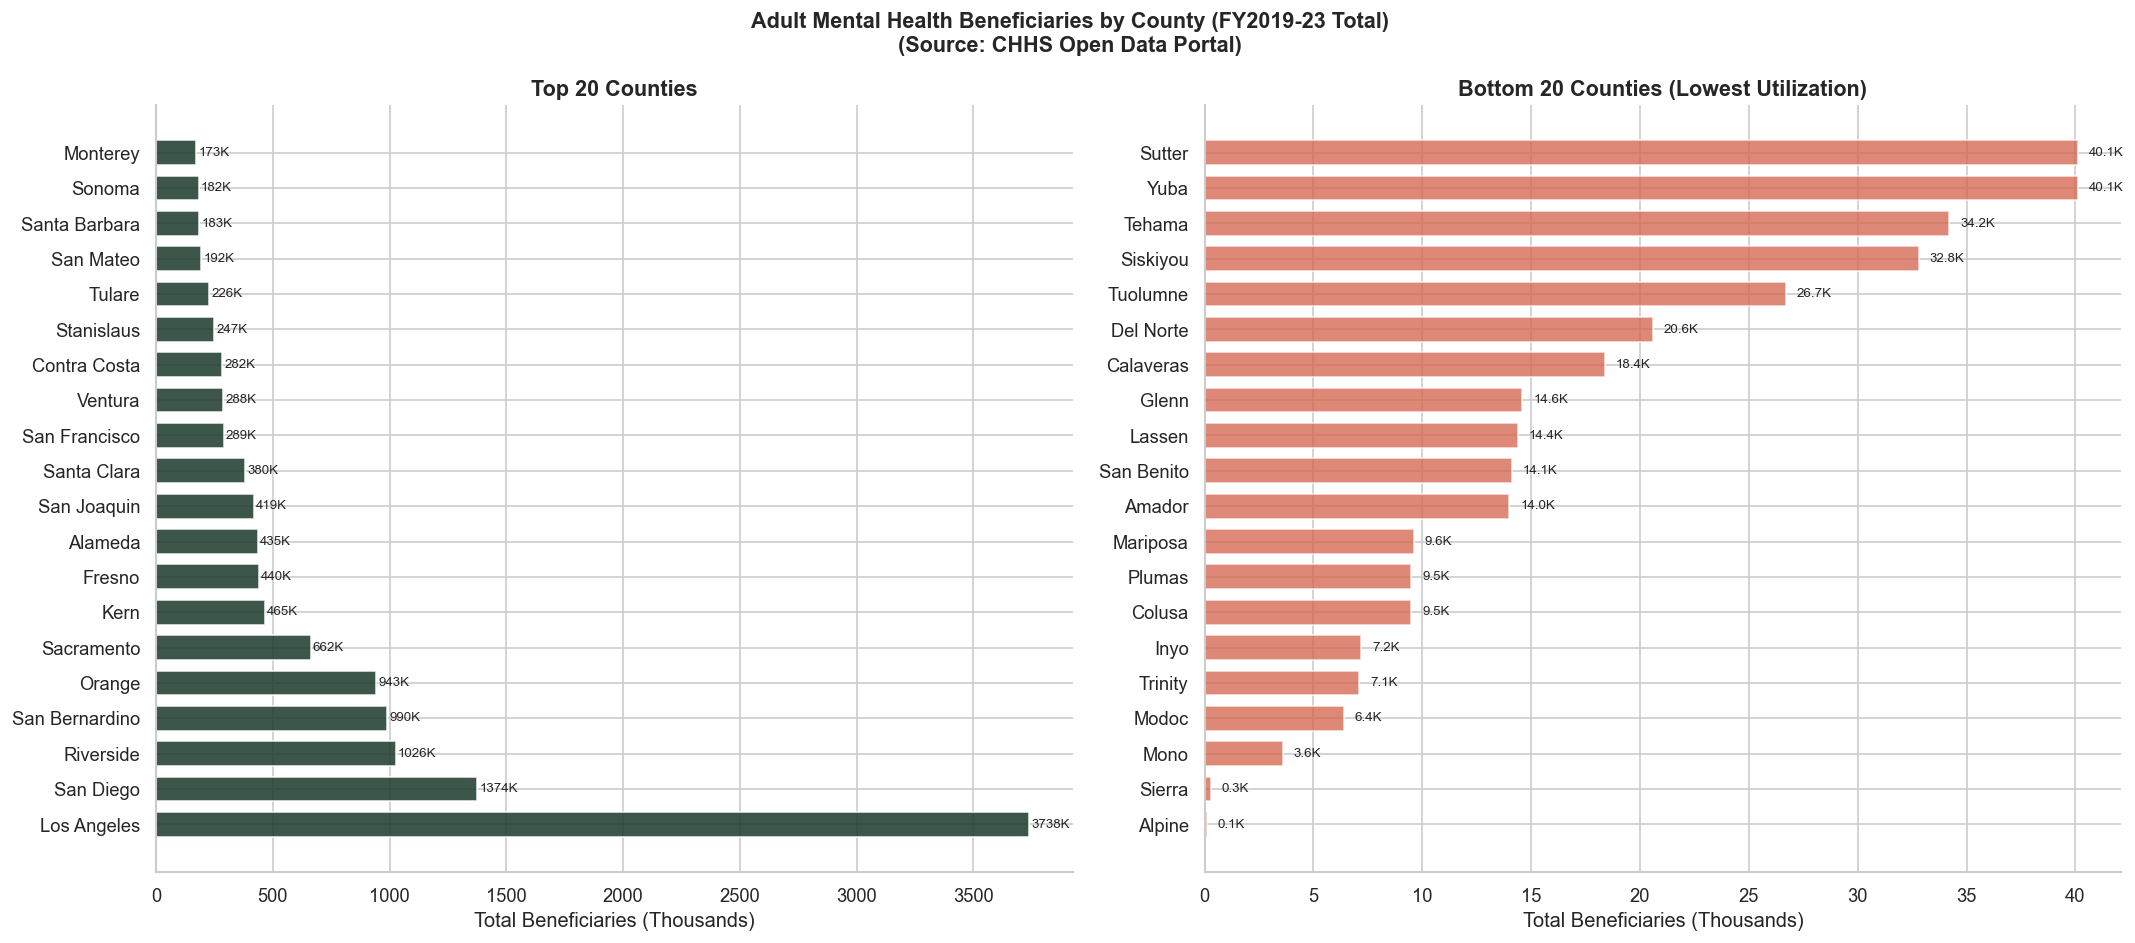

Highest: Los Angeles (3738K beneficiaries)
Lowest : Alpine (0.1K beneficiaries)


In [15]:
# Total beneficiaries per county across all years
# Exclude aggregate rows that are not actual counties
aggregate_rows = ['Statewide', 'Large Counties', 'Very Large Counties (LA)', 
                  'Medium Counties', 'Small Counties']

county_total = county_year[
    ~county_year['county'].isin(aggregate_rows) &
    ~county_year['county'].str.startswith('MCP-')
].groupby('county')['beneficiaries'].sum().sort_values(ascending=False).reset_index()
county_total['beneficiaries_K'] = (county_total['beneficiaries'] / 1000).round(1)

# Top 20 and Bottom 20
top20    = county_total.head(20)
bottom20 = county_total.tail(20).sort_values('beneficiaries')

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle('Adult Mental Health Beneficiaries by County (FY2019-23 Total)\n(Source: CHHS Open Data Portal)',
             fontsize=13, fontweight='bold')

# Top 20
bars1 = axes[0].barh(top20['county'], top20['beneficiaries_K'],
                     color=GREEN, alpha=0.85, height=0.7)
axes[0].set_title('Top 20 Counties')
axes[0].set_xlabel('Total Beneficiaries (Thousands)')
for bar, val in zip(bars1, top20['beneficiaries_K']):
    axes[0].text(val + 10, bar.get_y() + bar.get_height()/2,
                 f'{val:.0f}K', va='center', fontsize=8)

# Bottom 20
bars2 = axes[1].barh(bottom20['county'], bottom20['beneficiaries_K'],
                     color=RED, alpha=0.75, height=0.7)
axes[1].set_title('Bottom 20 Counties (Lowest Utilization)')
axes[1].set_xlabel('Total Beneficiaries (Thousands)')
for bar, val in zip(bars2, bottom20['beneficiaries_K']):
    axes[1].text(val + 0.5, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}K', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('02_county_analysis.png', bbox_inches='tight', dpi=150)
plt.show()

print(f'Highest: {top20.iloc[0]["county"]} ({top20.iloc[0]["beneficiaries_K"]:.0f}K beneficiaries)')
print(f'Lowest : {bottom20.iloc[0]["county"]} ({bottom20.iloc[0]["beneficiaries_K"]:.1f}K beneficiaries)')

## 06  Demographic Breakdown

Who is being served? Breaking down adult beneficiaries by sex, race and age group.

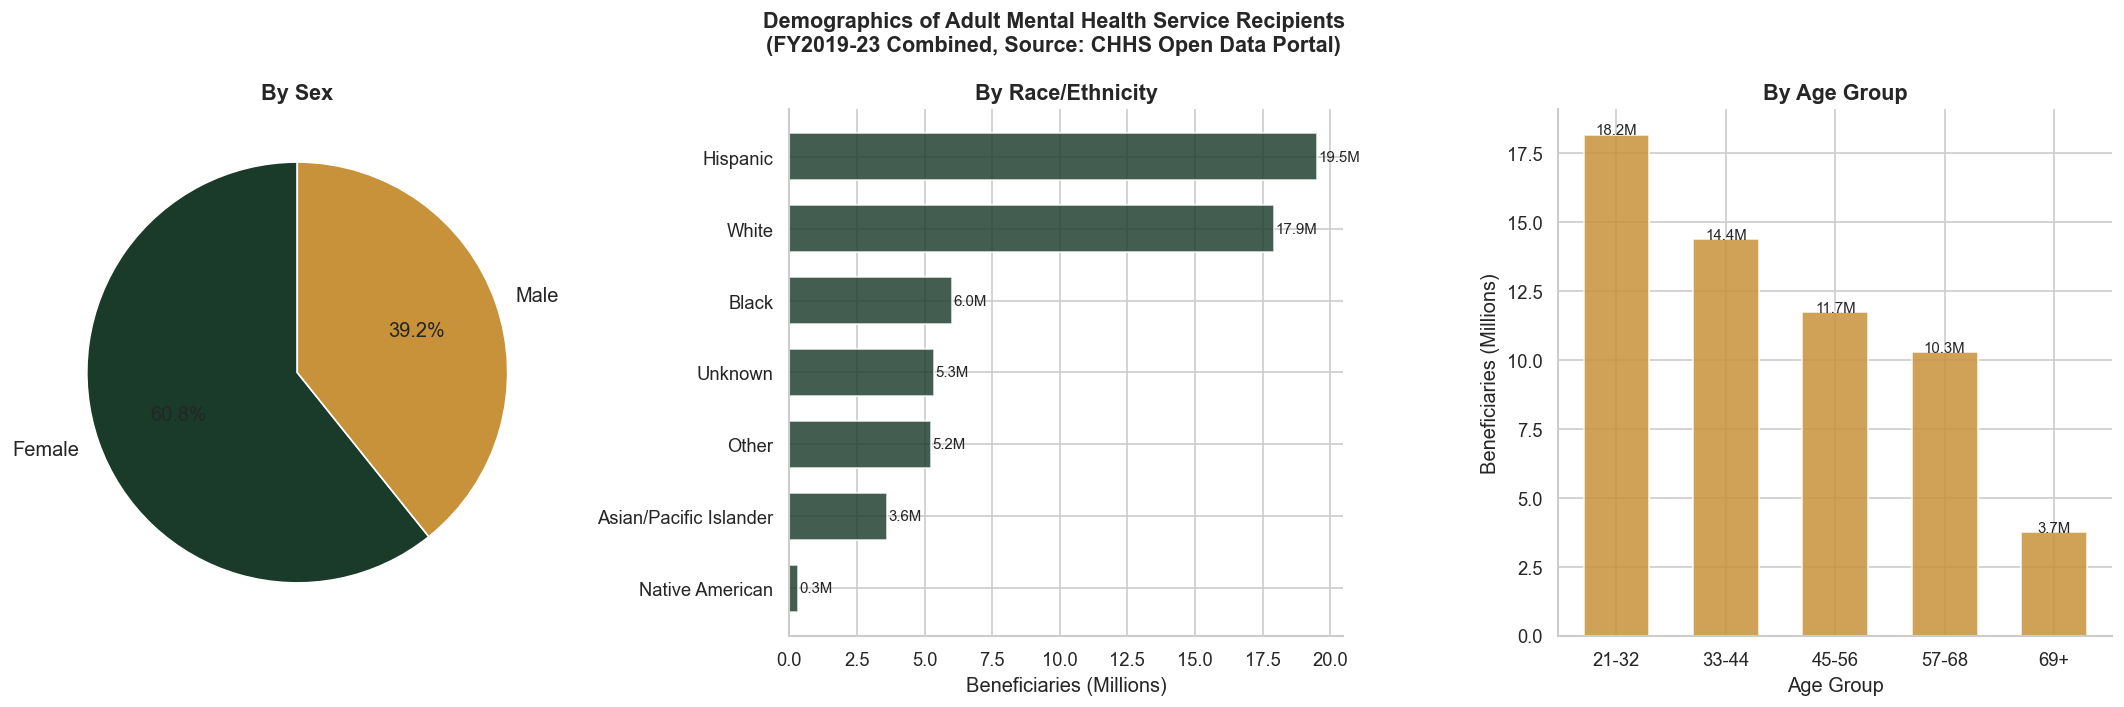

In [16]:
# SEX breakdown
sex_agg = sex_df[
    (sex_df['Population Category'] == 'Adult') &
    (sex_df['Units'] == 'BENE_COUNT') &
    (sex_df['Demographic Group'].isin(['S1 Female','S2 Male'])) &
    (~sex_df['Health Care Delivery System'].str.contains(' - ', na=False))
].groupby('Demographic Group')['Amount MH Service Received'].sum()
sex_agg.index = ['Female','Male']

# RACE breakdown
race_groups = {
    'R1 Alaskan Native or American Indian': 'Native American',
    'R2 Asian or Pacific Islander': 'Asian/Pacific Islander',
    'R3 Black': 'Black',
    'R4 Hispanic': 'Hispanic',
    'R5 White': 'White',
    'R6 Other': 'Other',
    'R7 Unknown': 'Unknown'
}
race_agg = race_df[
    (race_df['Population Category'] == 'Adult') &
    (race_df['Units'] == 'BENE_COUNT') &
    (race_df['Demographic Group'].isin(race_groups.keys())) &
    (~race_df['Health Care Delivery System'].str.contains(' - ', na=False))
].groupby('Demographic Group')['Amount MH Service Received'].sum()
race_agg.index = [race_groups[i] for i in race_agg.index]
race_agg = race_agg.sort_values(ascending=True)

# AGE breakdown
age_groups = {
    'A1 Adults 21-32': '21-32',
    'A2 Adults 33-44': '33-44',
    'A3 Adults 45-56': '45-56',
    'A4 Adults 57-68': '57-68',
    'A5 Adults 69+':   '69+'
}
age_agg = age_df[
    (age_df['Population Category'] == 'Adult') &
    (age_df['Units'] == 'BENE_COUNT') &
    (age_df['Demographic Group'].isin(age_groups.keys())) &
    (~age_df['Health Care Delivery System'].str.contains(' - ', na=False))
].groupby('Demographic Group')['Amount MH Service Received'].sum()
age_agg.index = [age_groups[i] for i in age_agg.index]

# Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Demographics of Adult Mental Health Service Recipients\n(FY2019-23 Combined, Source: CHHS Open Data Portal)',
             fontsize=13, fontweight='bold')

# Sex pie
axes[0].pie(sex_agg.values, labels=sex_agg.index, autopct='%1.1f%%',
            colors=[GREEN, GOLD], startangle=90,
            textprops={'fontsize': 12})
axes[0].set_title('By Sex')

# Race bar
bars = axes[1].barh(race_agg.index, race_agg.values / 1e6,
                    color=GREEN, alpha=0.82, height=0.65)
axes[1].set_title('By Race/Ethnicity')
axes[1].set_xlabel('Beneficiaries (Millions)')
for bar, val in zip(bars, race_agg.values / 1e6):
    axes[1].text(val + 0.05, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}M', va='center', fontsize=9)

# Age bar
axes[2].bar(age_agg.index, age_agg.values / 1e6,
            color=GOLD, alpha=0.85, width=0.6)
axes[2].set_title('By Age Group')
axes[2].set_xlabel('Age Group')
axes[2].set_ylabel('Beneficiaries (Millions)')
for i, val in enumerate(age_agg.values / 1e6):
    axes[2].text(i, val + 0.02, f'{val:.1f}M', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('03_demographics.png', bbox_inches='tight', dpi=150)
plt.show()

## 07  County Trends Over Time

How did the top 10 counties grow from FY2019-20 to FY2022-23? All showed consistent upward trends with no COVID dip.

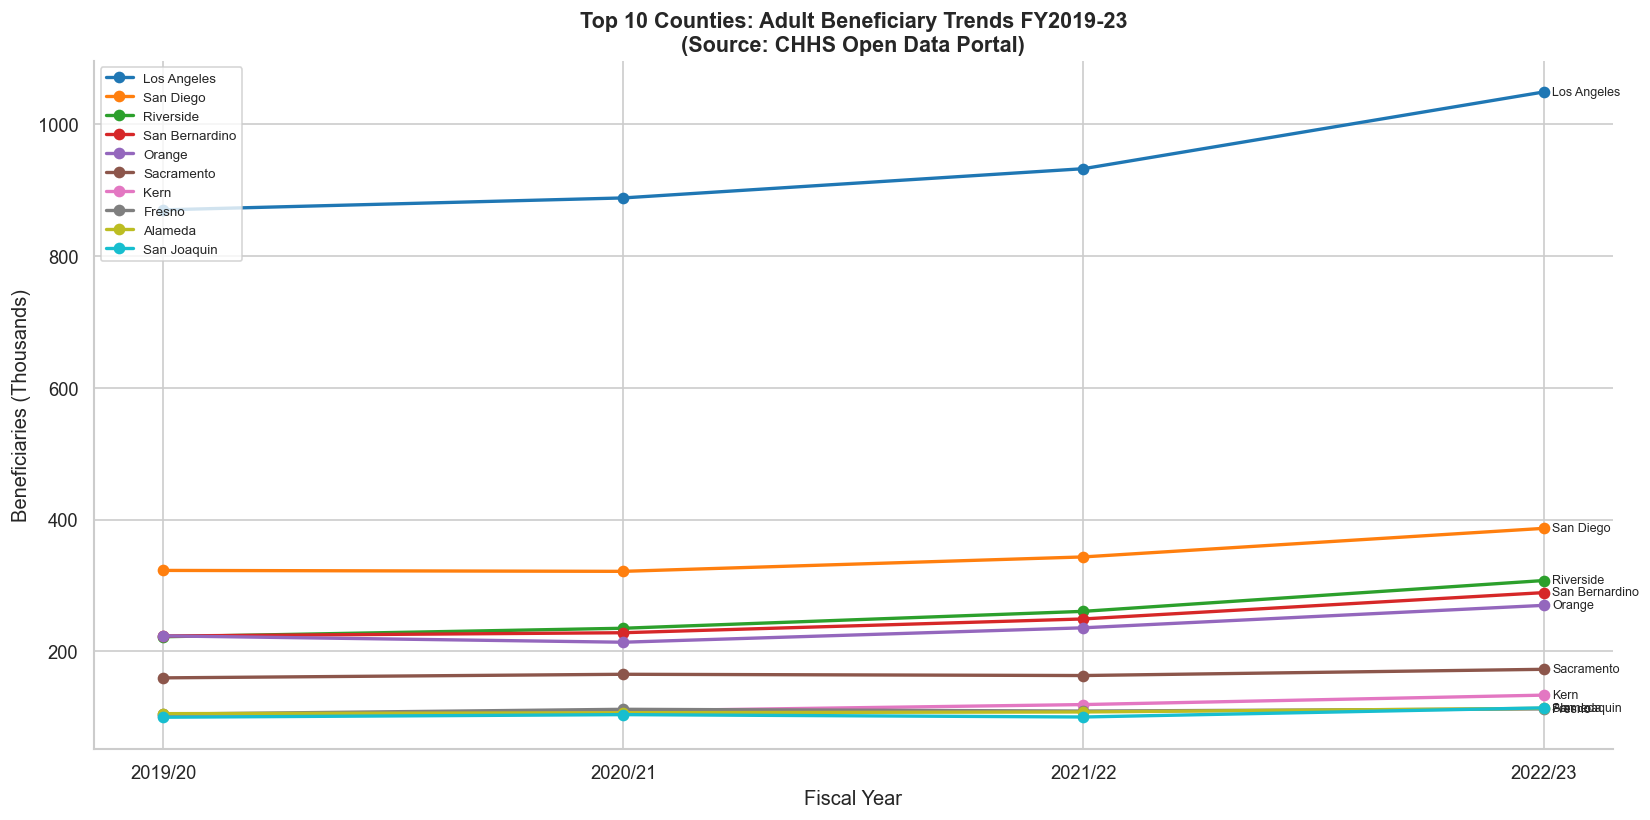

In [17]:
# Top 10 counties by total beneficiaries
top10_counties = county_total.head(10)['county'].tolist()

top10_trend = county_year[county_year['county'].isin(top10_counties)].copy()
top10_trend['beneficiaries_K'] = top10_trend['beneficiaries'] / 1000

fig, ax = plt.subplots(figsize=(14, 7))

colors_cycle = plt.cm.tab10.colors
for i, county in enumerate(top10_counties):
    subset = top10_trend[top10_trend['county'] == county].sort_values('fiscal_year')
    ax.plot(subset['fiscal_year'], subset['beneficiaries_K'],
            marker='o', linewidth=2, markersize=6,
            color=colors_cycle[i], label=county)
    # Label end point
    last = subset.iloc[-1]
    ax.annotate(county, xy=(last['fiscal_year'], last['beneficiaries_K']),
                xytext=(5, 0), textcoords='offset points',
                fontsize=7.5, va='center')

ax.set_title('Top 10 Counties: Adult Beneficiary Trends FY2019-23\n(Source: CHHS Open Data Portal)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Fiscal Year')
ax.set_ylabel('Beneficiaries (Thousands)')
ax.legend(fontsize=8, loc='upper left')

plt.tight_layout()
plt.savefig('04_county_trends.png', bbox_inches='tight', dpi=150)
plt.show()

## 08  Delivery System Comparison

SMHS (Specialty Mental Health Services) vs NSMHS (Non-Specialty). Which system serves more adults and how is that changing?

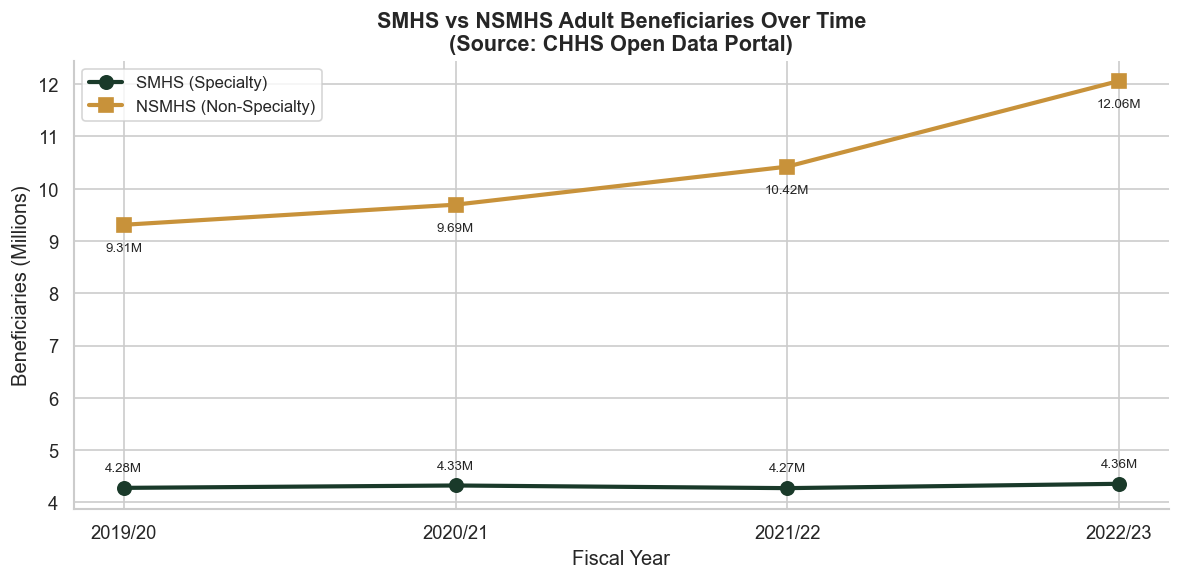

In [18]:
delivery = sex_df[
    (sex_df['Population Category'] == 'Adult') &
    (sex_df['Units'] == 'BENE_COUNT') &
    (sex_df['Demographic Group'] == 'S0 All') &
    (~sex_df['Health Care Delivery System'].str.contains(' - ', na=False))
].groupby(['Fiscal Year','Medi-Cal Delivery System'])['Amount MH Service Received'].sum().reset_index()

delivery['beneficiaries_M'] = delivery['Amount MH Service Received'] / 1e6

smhs  = delivery[delivery['Medi-Cal Delivery System'] == 'SMHS'].sort_values('Fiscal Year')
nsmhs = delivery[delivery['Medi-Cal Delivery System'] == 'NSMHS'].sort_values('Fiscal Year')

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(smhs['Fiscal Year'],  smhs['beneficiaries_M'],  marker='o', color=GREEN,
        linewidth=2.5, markersize=8, label='SMHS (Specialty)')
ax.plot(nsmhs['Fiscal Year'], nsmhs['beneficiaries_M'], marker='s', color=GOLD,
        linewidth=2.5, markersize=8, label='NSMHS (Non-Specialty)')

for _, row in smhs.iterrows():
    ax.annotate(f'{row["beneficiaries_M"]:.2f}M',
                xy=(row['Fiscal Year'], row['beneficiaries_M']),
                xytext=(0, 10), textcoords='offset points', ha='center', fontsize=8)
for _, row in nsmhs.iterrows():
    ax.annotate(f'{row["beneficiaries_M"]:.2f}M',
                xy=(row['Fiscal Year'], row['beneficiaries_M']),
                xytext=(0, -16), textcoords='offset points', ha='center', fontsize=8)

ax.set_title('SMHS vs NSMHS Adult Beneficiaries Over Time\n(Source: CHHS Open Data Portal)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Fiscal Year')
ax.set_ylabel('Beneficiaries (Millions)')
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('05_delivery_system.png', bbox_inches='tight', dpi=150)
plt.show()

## 09  Key Findings

In [20]:
total_all_years = county_year['beneficiaries'].sum()
top_county      = county_total.iloc[0]
bottom_county   = county_total.iloc[-1]
top_race        = race_agg.idxmax()
top_age         = age_agg.idxmax()
pct_female      = sex_agg['Female'] / sex_agg.sum() * 100

print('=' * 62)
print('  CALIFORNIA MENTAL HEALTH SERVICES: KEY FINDINGS')
print('  Source: CHHS Open Data Portal, FY2019-20 to FY2022-23')
print('=' * 62)
print(f'  Total adult beneficiaries (4 years) : {total_all_years:,.0f}')
print(f'  Growth FY2019-20 to FY2022-23       : +{total_growth:.1f}%')
print(f'  Highest volume county               : {top_county["county"]} ({top_county["beneficiaries_K"]:.0f}K)')
print(f'  Lowest volume county                : {bottom_county["county"]} ({bottom_county["beneficiaries_K"]:.1f}K)')
print(f'  Most served race/ethnicity          : {top_race}')
print(f'  Most served age group               : {top_age}')
print(f'  Female share of beneficiaries       : {pct_female:.1f}%')
print()
print('  WHAT THE DATA SHOWS:')
print('  1. Adult mental health utilization grew every year of the')
print('     study period, including through COVID-19. This may reflect')
print('     expanded Medi-Cal eligibility and telehealth adoption.')
print('  2. Los Angeles alone accounts for more beneficiaries than the')
print('     next 5 counties combined. Alpine county has just 100 served,')
print('     a 37,000x gap that reflects both population size and access.')
print('  3. Hispanic and White adults account for the largest share')
print('     of beneficiaries, reflecting California demographics.')
print('  4. The 21-32 and 33-44 age groups are the most served,')
print('     suggesting working-age adults are the primary recipients.')
print('  5. Female beneficiaries outnumber male in most counties,')
print('     consistent with national mental health service patterns.')
print('=' * 62)
print('  Next steps: Cross-reference with county poverty rates')
print('  and provider shortage area data to assess equity gaps.')
print('=' * 62)

  CALIFORNIA MENTAL HEALTH SERVICES: KEY FINDINGS
  Source: CHHS Open Data Portal, FY2019-20 to FY2022-23
  Total adult beneficiaries (4 years) : 58,725,048
  Growth FY2019-20 to FY2022-23       : +20.8%
  Highest volume county               : Los Angeles (3738K)
  Lowest volume county                : Alpine (0.1K)
  Most served race/ethnicity          : Hispanic
  Most served age group               : 21-32
  Female share of beneficiaries       : 60.8%

  WHAT THE DATA SHOWS:
  1. Adult mental health utilization grew every year of the
     study period, including through COVID-19. This may reflect
     expanded Medi-Cal eligibility and telehealth adoption.
  2. Los Angeles alone accounts for more beneficiaries than the
     next 5 counties combined. Alpine county has just 100 served,
     a 37,000x gap that reflects both population size and access.
  3. Hispanic and White adults account for the largest share
     of beneficiaries, reflecting California demographics.
  4. The 21-32 an

## Conclusion

This EDA reveals that California adult mental health service utilization grew consistently from FY2019-20 to FY2022-23, rising over the full period. The data is real, publicly available and sourced directly from the California Department of Health Care Services.

Key takeaways:

- Utilization grew year over year even during COVID-19, likely driven by telehealth expansion and Medi-Cal eligibility changes
- Los Angeles leads with 3.7M beneficiaries while rural counties like Alpine and Sierra serve under 1K. A gap that large is worth investigating beyond population size alone
- Hispanic and White adults represent the largest beneficiary groups by race
- Working-age adults (21-44) are the most served demographic
- Female beneficiaries consistently outnumber male across counties and years

This analysis forms the foundation for a county-level KPI dashboard (Project 03) that will allow interactive exploration of these trends.

---
*Data: California Health and Human Services Open Data Portal, data.chhs.ca.gov*  
*Dataset: Behavioral Health Program Performance Data, FY2019-20 to FY2022-23*  
*Author: Kesheka Edupuganti, keportfolio.vercel.app*